# Wafer CNN Classification (Normal vs Defect, 3% Defect Train)

This notebook trains a compact CNN for **binary wafer classification** using a training set intentionally constrained to **3% defect samples**.

Pipeline:
1. Load and clean WM-811K labels
2. Build train set with 97% normal / 3% defect
3. Convert wafer maps to 3-channel tensors
4. Train a CNN with weighted loss
5. Evaluate on validation and test splits
6. Save model + metrics artifacts

In [28]:
import os
import json
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    f1_score,
)

sns.set_theme(style='whitegrid')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_CUDA = DEVICE.type == 'cuda'
if USE_CUDA:
    torch.backends.cudnn.benchmark = True

print('Device:', DEVICE)

Device: cuda


In [ ]:
# Config
DATA_PATH = '../data/raw/LSWMD.pkl'
IMAGE_SIZE = 96

TRAIN_TOTAL = 40000
VAL_TOTAL = 5000
TEST_TOTAL = 5000
DEFECT_RATIO = 0.05

BATCH_SIZE = 256 if USE_CUDA else 128
NUM_WORKERS = 0
PIN_MEMORY = False

EPOCHS = 20
LR = 1e-3
WEIGHT_DECAY = 1e-4

# Auto LR + early stopping
LR_SCHED_FACTOR = 0.5
LR_SCHED_PATIENCE = 2
LR_SCHED_THRESHOLD = 1e-3
MIN_LR = 1e-6
EARLY_STOP_PATIENCE = 6
EARLY_STOP_MIN_DELTA = 1e-3

ARTIFACT_DIR = '../artifacts/x64/cnn_wafer_normal_3pct_defect'
MODEL_PATH = os.path.join(ARTIFACT_DIR, 'cnn_wafer_classifier.pt')
METRICS_PATH = os.path.join(ARTIFACT_DIR, 'cnn_metrics.json')
os.makedirs(ARTIFACT_DIR, exist_ok=True)

print('Artifacts:', ARTIFACT_DIR)
print(
    f'splits -> train={TRAIN_TOTAL}, val={VAL_TOTAL}, test={TEST_TOTAL}, '
    f'defect_ratio={DEFECT_RATIO:.2%}'
)
print(
    f'training -> epochs={EPOCHS}, lr={LR}, wd={WEIGHT_DECAY}, '
    f'lr_factor={LR_SCHED_FACTOR}, lr_patience={LR_SCHED_PATIENCE}, '
    f'early_stop_patience={EARLY_STOP_PATIENCE}'
)

Artifacts: ../artifacts/x64/cnn_wafer_normal_3pct_defect
splits -> train=100000, val=10000, test=10000, defect_ratio=1.00%
training -> epochs=20, lr=0.001, wd=0.0001, lr_factor=0.5, lr_patience=2, early_stop_patience=6


In [30]:
# Load and clean labels
df = pd.read_pickle(DATA_PATH)
print('Raw shape:', df.shape)

def parse_failure_label(value):
    if value is None:
        return 'unknown'
    if isinstance(value, float) and np.isnan(value):
        return 'unknown'
    if isinstance(value, (list, tuple, np.ndarray)):
        arr = np.array(value).reshape(-1)
        if len(arr) == 0:
            return 'unknown'
        return str(arr[0])
    return str(value)

df = df.copy()
df['failure_label'] = df['failureType'].apply(parse_failure_label).astype(str).str.strip()
invalid = {'0', 'unknown', 'nan', 'None', '[]'}
df = df[~df['failure_label'].isin(invalid)].copy()
df['is_anomaly'] = (df['failure_label'].str.lower() != 'none').astype(int)

normal_df = df[df['is_anomaly'] == 0].copy()
defect_df = df[df['is_anomaly'] == 1].copy()

print('Labeled shape:', df.shape)
print('Normal count:', len(normal_df))
print('Defect count:', len(defect_df))

Raw shape: (811457, 6)
Labeled shape: (172950, 8)
Normal count: 147431
Defect count: 25519


In [31]:
# Build train/val/test splits with exactly 3% defects each
def split_counts(total_n, defect_ratio):
    defect_n = max(1, int(round(total_n * defect_ratio)))
    normal_n = total_n - defect_n
    return normal_n, defect_n

train_normal_n, train_defect_n = split_counts(TRAIN_TOTAL, DEFECT_RATIO)
val_normal_n, val_defect_n = split_counts(VAL_TOTAL, DEFECT_RATIO)
test_normal_n, test_defect_n = split_counts(TEST_TOTAL, DEFECT_RATIO)

need_normals = train_normal_n + val_normal_n + test_normal_n
need_defects = train_defect_n + val_defect_n + test_defect_n

if len(normal_df) < need_normals:
    raise ValueError(f'Not enough normal samples: need {need_normals}, got {len(normal_df)}')
if len(defect_df) < need_defects:
    raise ValueError(f'Not enough defect samples: need {need_defects}, got {len(defect_df)}')

rng = np.random.default_rng(SEED)
normal_idx = rng.permutation(len(normal_df))
defect_idx = rng.permutation(len(defect_df))

normal_df_shuf = normal_df.iloc[normal_idx].reset_index(drop=True)
defect_df_shuf = defect_df.iloc[defect_idx].reset_index(drop=True)

n0 = 0
n1 = train_normal_n
n2 = train_normal_n + val_normal_n
n3 = train_normal_n + val_normal_n + test_normal_n

d0 = 0
d1 = train_defect_n
d2 = train_defect_n + val_defect_n
d3 = train_defect_n + val_defect_n + test_defect_n

train_df = pd.concat([
    normal_df_shuf.iloc[n0:n1].copy(),
    defect_df_shuf.iloc[d0:d1].copy(),
], ignore_index=True)
val_df = pd.concat([
    normal_df_shuf.iloc[n1:n2].copy(),
    defect_df_shuf.iloc[d1:d2].copy(),
], ignore_index=True)
test_df = pd.concat([
    normal_df_shuf.iloc[n2:n3].copy(),
    defect_df_shuf.iloc[d2:d3].copy(),
], ignore_index=True)

train_df = train_df.sample(frac=1.0, random_state=SEED).reset_index(drop=True)
val_df = val_df.sample(frac=1.0, random_state=SEED).reset_index(drop=True)
test_df = test_df.sample(frac=1.0, random_state=SEED).reset_index(drop=True)

def pct_defect(frame):
    return 100.0 * frame['is_anomaly'].mean()

print('Train:', len(train_df), '| normal:', int((train_df['is_anomaly'] == 0).sum()), '| defect:', int((train_df['is_anomaly'] == 1).sum()), '| defect %:', f'{pct_defect(train_df):.2f}')
print('Val  :', len(val_df),   '| normal:', int((val_df['is_anomaly'] == 0).sum()),   '| defect:', int((val_df['is_anomaly'] == 1).sum()),   '| defect %:', f'{pct_defect(val_df):.2f}')
print('Test :', len(test_df),  '| normal:', int((test_df['is_anomaly'] == 0).sum()),  '| defect:', int((test_df['is_anomaly'] == 1).sum()),  '| defect %:', f'{pct_defect(test_df):.2f}')

Train: 100000 | normal: 99000 | defect: 1000 | defect %: 1.00
Val  : 10000 | normal: 9900 | defect: 100 | defect %: 1.00
Test : 10000 | normal: 9900 | defect: 100 | defect %: 1.00


In [32]:
def wafer_to_tensor(wafer_map, size=96):
    arr = np.array(wafer_map, dtype=np.int64)
    arr = np.clip(arr, 0, 2)
    x = torch.tensor(arr, dtype=torch.long)
    x = F.one_hot(x, num_classes=3).permute(2, 0, 1).float()
    x = x.unsqueeze(0)
    x = F.interpolate(x, size=(size, size), mode='nearest')
    return x.squeeze(0)

def build_tensor(frame, size=96):
    imgs = [wafer_to_tensor(w, size=size) for w in frame['waferMap'].values]
    X = torch.stack(imgs)
    y = torch.tensor(frame['is_anomaly'].values, dtype=torch.float32)
    return X, y

X_train, y_train = build_tensor(train_df, IMAGE_SIZE)
X_val, y_val = build_tensor(val_df, IMAGE_SIZE)
X_test, y_test = build_tensor(test_df, IMAGE_SIZE)

loader_kwargs = {
    'batch_size': BATCH_SIZE,
    'num_workers': NUM_WORKERS,
    'pin_memory': PIN_MEMORY,
}

train_loader = DataLoader(TensorDataset(X_train, y_train), shuffle=True, **loader_kwargs)
val_loader = DataLoader(TensorDataset(X_val, y_val), shuffle=False, **loader_kwargs)
test_loader = DataLoader(TensorDataset(X_test, y_test), shuffle=False, **loader_kwargs)

print('X_train:', tuple(X_train.shape), '| y_train mean:', float(y_train.mean()))
print('X_val  :', tuple(X_val.shape),   '| y_val mean:', float(y_val.mean()))
print('X_test :', tuple(X_test.shape),  '| y_test mean:', float(y_test.mean()))

X_train: (100000, 3, 96, 96) | y_train mean: 0.009999999776482582
X_val  : (10000, 3, 96, 96) | y_val mean: 0.009999999776482582
X_test : (10000, 3, 96, 96) | y_test mean: 0.009999999776482582


In [33]:
class WaferCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.25),
            nn.Linear(256, 1),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x).squeeze(1)

model = WaferCNN().to(DEVICE)

n_pos = max(1, int(y_train.sum().item()))
n_neg = max(1, int(len(y_train) - n_pos))
pos_weight = torch.tensor([n_neg / n_pos], device=DEVICE, dtype=torch.float32)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

print('pos_weight:', float(pos_weight.item()))

pos_weight: 99.0


In [34]:
def evaluate(model, loader):
    model.eval()
    probs_all = []
    y_all = []
    loss_sum = 0.0

    with torch.inference_mode():
        for xb, yb in loader:
            xb = xb.to(DEVICE, non_blocking=PIN_MEMORY)
            yb = yb.to(DEVICE, non_blocking=PIN_MEMORY)

            logits = model(xb)
            loss = criterion(logits, yb)
            probs = torch.sigmoid(logits)

            loss_sum += float(loss.item()) * len(xb)
            probs_all.append(probs.detach().cpu())
            y_all.append(yb.detach().cpu())

    probs = torch.cat(probs_all).numpy()
    y_true = torch.cat(y_all).numpy().astype(int)
    y_pred = (probs >= 0.5).astype(int)

    metrics = {
        'loss': loss_sum / len(loader.dataset),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_true, probs) if len(np.unique(y_true)) > 1 else np.nan,
    }
    return metrics, y_true, y_pred, probs

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=LR_SCHED_FACTOR,
    patience=LR_SCHED_PATIENCE,
    threshold=LR_SCHED_THRESHOLD,
    min_lr=MIN_LR,
    eps=1e-8,
)

history = []
best_val_f1 = -1.0
best_state = None
best_epoch = 0
epochs_without_improve = 0

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_loss_sum = 0.0

    for xb, yb in train_loader:
        xb = xb.to(DEVICE, non_blocking=PIN_MEMORY)
        yb = yb.to(DEVICE, non_blocking=PIN_MEMORY)

        optimizer.zero_grad(set_to_none=True)
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        train_loss_sum += float(loss.item()) * len(xb)

    train_loss = train_loss_sum / len(train_loader.dataset)
    val_metrics, _, _, _ = evaluate(model, val_loader)

    current_lr = optimizer.param_groups[0]['lr']
    row = {
        'epoch': epoch,
        'lr': current_lr,
        'train_loss': train_loss,
        'val_loss': val_metrics['loss'],
        'val_f1': val_metrics['f1'],
        'val_roc_auc': val_metrics['roc_auc'],
    }
    history.append(row)

    if val_metrics['f1'] > (best_val_f1 + EARLY_STOP_MIN_DELTA):
        best_val_f1 = val_metrics['f1']
        best_epoch = epoch
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        epochs_without_improve = 0
    else:
        epochs_without_improve += 1

    scheduler.step(val_metrics['f1'])
    next_lr = optimizer.param_groups[0]['lr']

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | lr={current_lr:.2e} | train_loss={train_loss:.4f} | "
        f"val_loss={val_metrics['loss']:.4f} | val_f1={val_metrics['f1']:.4f} | "
        f"val_auc={val_metrics['roc_auc']:.4f} | next_lr={next_lr:.2e}"
    )

    if epochs_without_improve >= EARLY_STOP_PATIENCE:
        print(
            f"Early stopping at epoch {epoch}: no val_f1 improvement > {EARLY_STOP_MIN_DELTA} "
            f"for {EARLY_STOP_PATIENCE} epochs."
        )
        break

if best_state is not None:
    model.load_state_dict(best_state)

print(f'Best validation F1: {best_val_f1:.4f} at epoch {best_epoch}')
history_df = pd.DataFrame(history)
display(history_df.tail())

Epoch 01/20 | lr=1.00e-03 | train_loss=0.5735 | val_loss=0.3612 | val_f1=0.3554 | val_auc=0.9828 | next_lr=1.00e-03
Epoch 02/20 | lr=1.00e-03 | train_loss=0.4144 | val_loss=0.3121 | val_f1=0.5212 | val_auc=0.9899 | next_lr=1.00e-03
Epoch 03/20 | lr=1.00e-03 | train_loss=0.3699 | val_loss=0.5416 | val_f1=0.7054 | val_auc=0.9739 | next_lr=1.00e-03
Epoch 04/20 | lr=1.00e-03 | train_loss=0.3320 | val_loss=0.5220 | val_f1=0.8587 | val_auc=0.9930 | next_lr=1.00e-03
Epoch 05/20 | lr=1.00e-03 | train_loss=0.3245 | val_loss=0.2797 | val_f1=0.3563 | val_auc=0.9912 | next_lr=1.00e-03
Epoch 06/20 | lr=1.00e-03 | train_loss=0.3229 | val_loss=0.6052 | val_f1=0.6311 | val_auc=0.9658 | next_lr=1.00e-03
Epoch 07/20 | lr=1.00e-03 | train_loss=0.2703 | val_loss=0.9512 | val_f1=0.0628 | val_auc=0.9825 | next_lr=5.00e-04
Epoch 08/20 | lr=5.00e-04 | train_loss=0.2205 | val_loss=0.2420 | val_f1=0.4932 | val_auc=0.9928 | next_lr=5.00e-04
Epoch 09/20 | lr=5.00e-04 | train_loss=0.1891 | val_loss=0.3108 | val_f1

,epoch,lr,train_loss,val_loss,val_f1,val_roc_auc
5,6,0.0010,0.322892,0.605190,0.631148,0.965812
6,7,0.0010,0.270324,0.951157,0.062821,0.982507
7,8,0.0005,0.220473,0.241976,0.493151,0.992815
8,9,0.0005,0.189076,0.310791,0.613240,0.988976
9,10,0.0005,0.169703,0.462162,0.097135,0.993138


Test loss   : 0.6617
Test F1     : 0.8404
Test ROC-AUC: 0.9665

              precision    recall  f1-score   support

      normal       1.00      1.00      1.00      9900
      defect       0.90      0.79      0.84       100

    accuracy                           1.00     10000
   macro avg       0.95      0.89      0.92     10000
weighted avg       1.00      1.00      1.00     10000



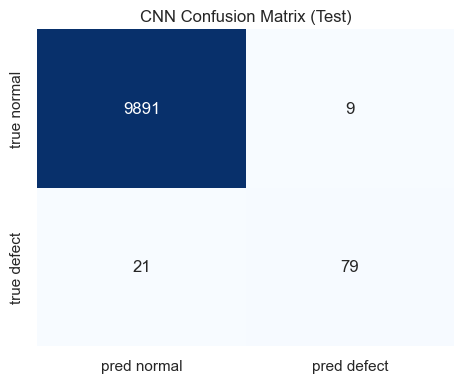

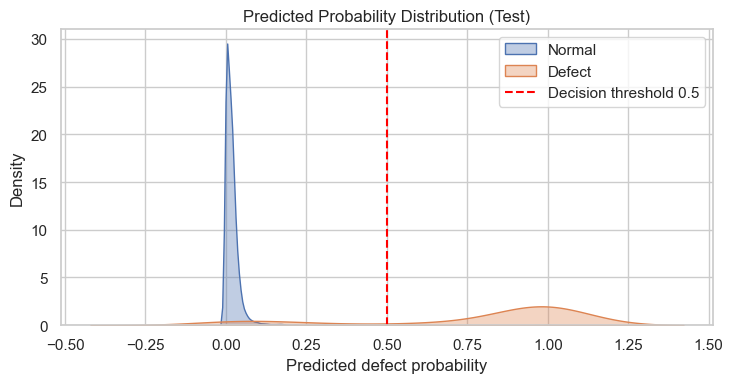

In [35]:
# Final test evaluation
test_metrics, y_true, y_pred, y_prob = evaluate(model, test_loader)

print('Test loss   :', f"{test_metrics['loss']:.4f}")
print('Test F1     :', f"{test_metrics['f1']:.4f}")
print('Test ROC-AUC:', f"{test_metrics['roc_auc']:.4f}")
print()
print(classification_report(y_true, y_pred, target_names=['normal', 'defect'], zero_division=0))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(4.8, 4.0))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    xticklabels=['pred normal', 'pred defect'],
    yticklabels=['true normal', 'true defect'],
)
plt.title('CNN Confusion Matrix (Test)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(7.5, 4.0))
sns.kdeplot(y_prob[y_true == 0], label='Normal', fill=True, alpha=0.35)
sns.kdeplot(y_prob[y_true == 1], label='Defect', fill=True, alpha=0.35)
plt.axvline(0.5, color='red', linestyle='--', label='Decision threshold 0.5')
plt.xlabel('Predicted defect probability')
plt.ylabel('Density')
plt.title('Predicted Probability Distribution (Test)')
plt.legend()
plt.tight_layout()
plt.show()

In [37]:
# Defect wafer scores and labels per class
if 'failure_label' not in test_df.columns:
    raise ValueError("test_df does not contain 'failure_label'.")

defect_mask = (y_true == 1)
defect_scores = y_prob[defect_mask]
defect_pred = y_pred[defect_mask]

defect_details = test_df.loc[defect_mask, ['failure_label']].copy().reset_index(drop=True)
defect_details['defect_score'] = defect_scores
defect_details['pred_label'] = np.where(defect_pred == 1, 'defect', 'normal')
defect_details['is_detected'] = defect_pred.astype(int)

print('Defect wafer score list (top 20 by score):')
display(defect_details.sort_values('defect_score', ascending=False).head(20))

per_class = (
    defect_details.groupby('failure_label', as_index=False)
    .agg(
        count=('is_detected', 'count'),
        detected=('is_detected', 'sum'),
        recall=('is_detected', 'mean'),
        mean_score=('defect_score', 'mean'),
        median_score=('defect_score', 'median'),
        min_score=('defect_score', 'min'),
        max_score=('defect_score', 'max'),
    )
    .sort_values(['recall', 'mean_score'], ascending=[True, False])
    .reset_index(drop=True)
)

print('Per-class defect score and detection summary:')
display(per_class)

Defect wafer score list (top 20 by score):


,failure_label,defect_score,pred_label,is_detected
34,Edge-Loc,1.0,defect,1
63,Random,1.0,defect,1
66,Donut,1.0,defect,1
70,Center,1.0,defect,1
56,Edge-Ring,1.0,defect,1
21,Center,1.0,defect,1
1,Edge-Loc,1.0,defect,1
48,Random,1.0,defect,1
83,Loc,1.0,defect,1
64,Edge-Loc,1.0,defect,1


Per-class defect score and detection summary:


,failure_label,count,detected,recall,mean_score,median_score,min_score,max_score
0,Scratch,3,1,0.333333,0.415312,0.267613,0.001693,0.976629
1,Edge-Loc,21,10,0.476190,0.543834,0.478635,0.007496,1.000000
2,Loc,14,9,0.642857,0.610344,0.734371,0.027310,1.000000
3,Center,17,14,0.823529,0.767418,0.964290,0.000934,1.000000
4,Donut,3,3,1.000000,1.000000,1.000000,1.000000,1.000000
5,Random,3,3,1.000000,1.000000,1.000000,1.000000,1.000000
6,Edge-Ring,39,39,1.000000,0.965218,0.999335,0.590941,1.000000


In [ ]:
# Save artifacts
artifact = {
    'state_dict': model.state_dict(),
    'image_size': IMAGE_SIZE,
    'train_total': TRAIN_TOTAL,
    'val_total': VAL_TOTAL,
    'test_total': TEST_TOTAL,
    'target_defect_ratio': DEFECT_RATIO,
    'best_val_f1': float(best_val_f1),
    'best_epoch': int(best_epoch),
    'scheduler': {
        'name': 'ReduceLROnPlateau',
        'factor': LR_SCHED_FACTOR,
        'patience': LR_SCHED_PATIENCE,
        'threshold': LR_SCHED_THRESHOLD,
        'min_lr': MIN_LR,
    },
    'early_stopping': {
        'patience': EARLY_STOP_PATIENCE,
        'min_delta': EARLY_STOP_MIN_DELTA,
    },
}
torch.save(artifact, MODEL_PATH)

metrics = {
    'test_loss': float(test_metrics['loss']),
    'test_f1': float(test_metrics['f1']),
    'test_roc_auc': float(test_metrics['roc_auc']),
    'best_val_f1': float(best_val_f1),
    'best_epoch': int(best_epoch),
    'epochs_ran': int(len(history_df)),
    'final_lr': float(optimizer.param_groups[0]['lr']),
    'train_count': int(len(train_df)),
    'val_count': int(len(val_df)),
    'test_count': int(len(test_df)),
    'target_defect_ratio': float(DEFECT_RATIO),
    'train_defect_percent': float(100.0 * train_df['is_anomaly'].mean()),
    'val_defect_percent': float(100.0 * val_df['is_anomaly'].mean()),
    'test_defect_percent': float(100.0 * test_df['is_anomaly'].mean()),
    'confusion_matrix': cm.tolist(),
    'defect_per_class': per_class.to_dict(orient='records'),
}
with open(METRICS_PATH, 'w', encoding='utf-8') as f:
    json.dump(metrics, f, indent=2)

print('Saved model to:', MODEL_PATH)
print('Saved metrics to:', METRICS_PATH)

Saved model to: ../artifacts/x64/cnn_wafer_normal_3pct_defect\cnn_wafer_classifier.pt
Saved metrics to: ../artifacts/x64/cnn_wafer_normal_3pct_defect\cnn_metrics.json
